# Predicting wine quality with binary classification using knn algorithm

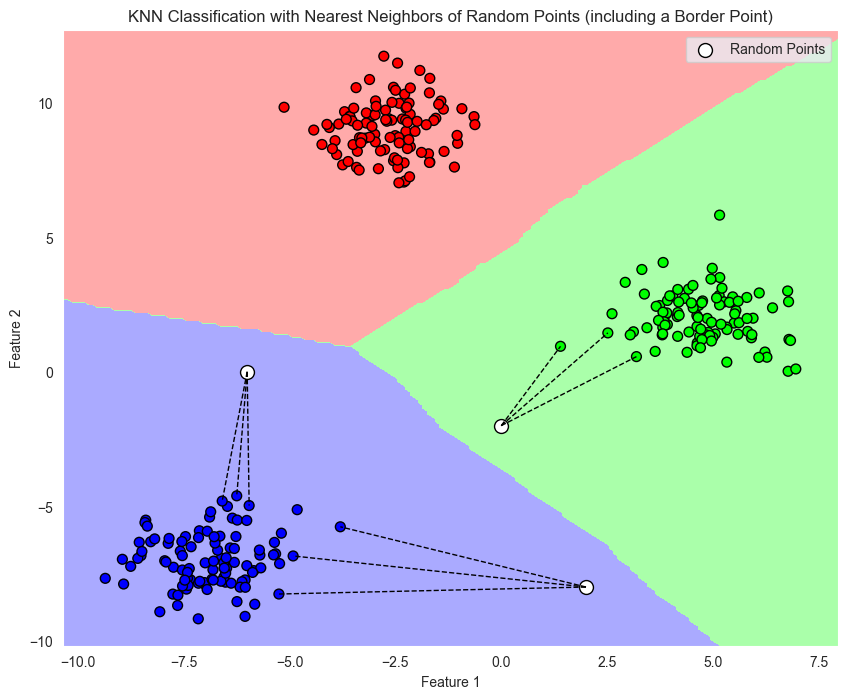

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

X, y = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=1.0)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(10, 8), dpi=100)
plt.contourf(xx, yy, Z, cmap=cmap_light)

scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=50)
plt.legend(handles=scatter.legend_elements()[0], labels=['Class 0', 'Class 1', 'Class 2'])

random_points = np.array([[2, -8], [-6, 0], [0, -2]])  # last point [0, -2] is on the border
plt.scatter(random_points[:, 0], random_points[:, 1], c='white', edgecolor='black', s=100, label='Random Points')

for i, point in enumerate(random_points):
    num_neighbors = 3 if i < 2 else 3  # set 3 neighbors for the first two points, 5 for the border point
    distances, indices = knn.kneighbors([point], n_neighbors=num_neighbors)
    for neighbor_idx in indices[0]:
        neighbor = X[neighbor_idx]
        plt.plot([point[0], neighbor[0]], [point[1], neighbor[1]], 'k--', linewidth=1)
plt.title("KNN Classification with Nearest Neighbors of Random Points (including a Border Point)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.legend()
plt.show()

##### this dataset is related to red wine quality and the goal is to predict the quality of the wine based on the features of the wine.
##### the dataset contains 11 feature columns and 1 class as well as 1599 rows.
##### the columns are:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol
- quality
- the quality column is going to be converted to binary column where the quality value >= 6 is going to be considered as good quality and the quality value < 6 is going to be considered as bad quality.   

#### step 1
##### importing the dataframe and checking a sample of the data

In [79]:
import pandas as pd

redwine_df = pd.read_csv('../winequality-red-clean.csv', sep=',')

redwine_df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1070,-0.068128,-1.027241,0.338477,0.013043,-0.262062,-0.439085,0.113515,-0.423635,-0.327854,1.292021,0.571445,6
212,-0.371707,0.034478,-1.073614,-0.796196,-0.355998,-0.653805,-0.158557,-0.330497,0.238930,-1.252151,-0.604721,6
187,-0.310991,0.034478,0.338477,0.013043,-0.074189,0.956592,3.412382,-0.097653,-0.115310,-0.326998,-0.898763,5
1181,-0.189560,-1.440132,0.913774,-0.680590,-0.027221,1.386031,0.827702,-0.994103,0.309778,0.135579,0.767472,5
746,1.267617,-0.496381,0.809175,-1.027407,2.978739,2.030190,0.147524,0.932682,0.451474,1.677502,-0.506707,3


#### step 2
##### inspecting the dataset , datatypes and names of the columns

In [80]:
info_data = {"Column": redwine_df.columns,"Non-Null Count": redwine_df.notnull().sum(),"Dtype": redwine_df.dtypes}

info_df = pd.DataFrame(info_data)

print("Red Wine DataFrame Info:")

info_df

Red Wine DataFrame Info:


,Column,Non-Null Count,Dtype
fixed acidity,fixed acidity,1458,float64
volatile acidity,volatile acidity,1458,float64
citric acid,citric acid,1458,float64
residual sugar,residual sugar,1458,float64
chlorides,chlorides,1458,float64
free sulfur dioxide,free sulfur dioxide,1458,float64
total sulfur dioxide,total sulfur dioxide,1458,float64
density,density,1458,float64
pH,pH,1458,float64
sulphates,sulphates,1458,float64


#### step 3
##### Simple statistics of the dataset describing the mean, standard deviation, minimum, maximum, and quartiles of the data.

In [81]:
redwine_df.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1458.000000,-0.000000,1.000343,-2.011030,-0.736001,-0.250275,0.539029,3.149804
volatile acidity,1458.000000,0.000000,1.000343,-2.383882,-0.791303,-0.024506,0.653815,3.042683
citric acid,1458.000000,-0.000000,1.000343,-1.387413,-0.916715,-0.079920,0.809175,2.744263
residual sugar,1458.000000,0.000000,1.000343,-1.374224,-0.564985,-0.218168,0.244255,4.984085
chlorides,1458.000000,0.000000,1.000343,-2.046850,-0.543870,-0.121157,0.348524,6.783157
free sulfur dioxide,1458.000000,-0.000000,1.000343,-1.512683,-0.868525,-0.224366,0.634513,3.425867
total sulfur dioxide,1458.000000,-0.000000,1.000343,-1.280852,-0.770718,-0.260584,0.487613,3.446391
density,1458.000000,-0.000000,1.000343,-3.037311,-0.650658,-0.010337,0.629985,3.191270
pH,1458.000000,0.000000,1.000343,-3.090926,-0.682094,-0.009038,0.593170,3.072849
sulphates,1458.000000,0.000000,1.000343,-2.408593,-0.712478,-0.172805,0.598156,3.990386


#### step 4
##### checking the distribution of the quality column

In [82]:
redwine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

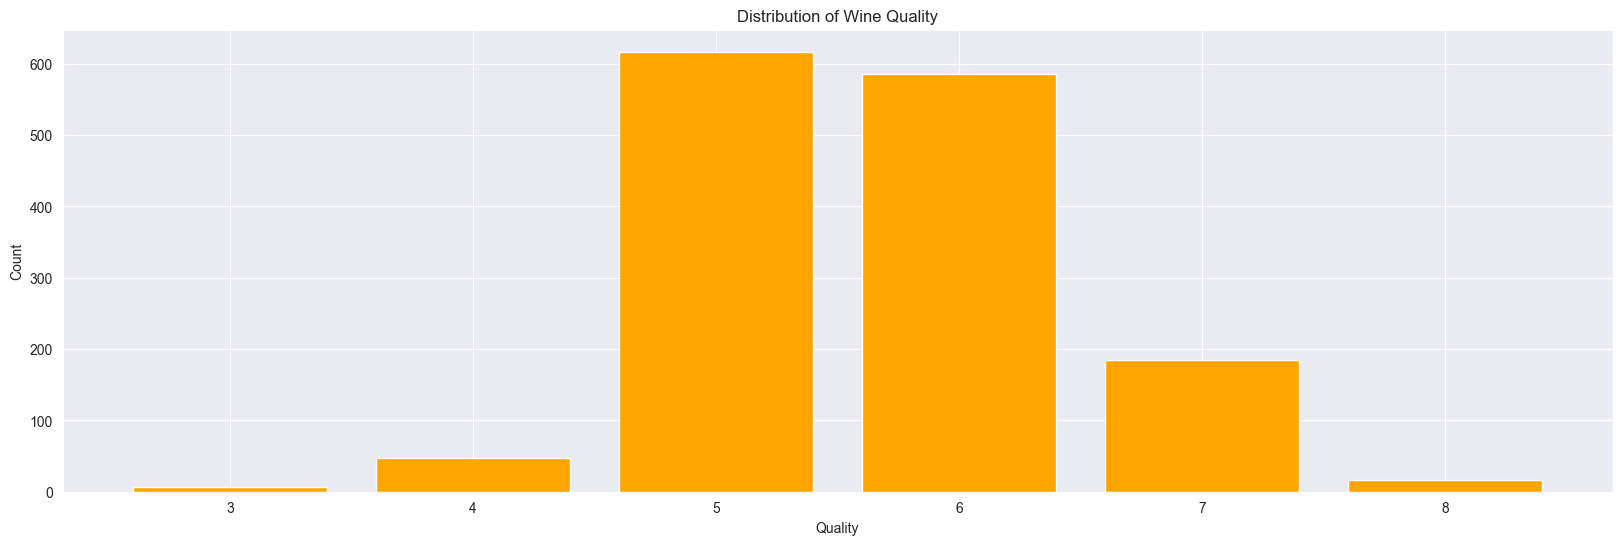

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

quality_counts = redwine_df['quality'].value_counts().sort_index()

quality_df = pd.DataFrame({'quality': quality_counts.index, 'count': quality_counts.values})

# plotting the bar chart
plt.figure(figsize=(20, 6))
plt.bar(quality_df['quality'], quality_df['count'], color='orange')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality')
plt.xticks(quality_df['quality'])  # the x-axis labels match the quality values
plt.show()

##### as we can see the data is not balanced, since I am going to do a binary classification, that is naturally going t help me to balance the data.

#### step 5
##### checking the correlation of the data using the heatmap

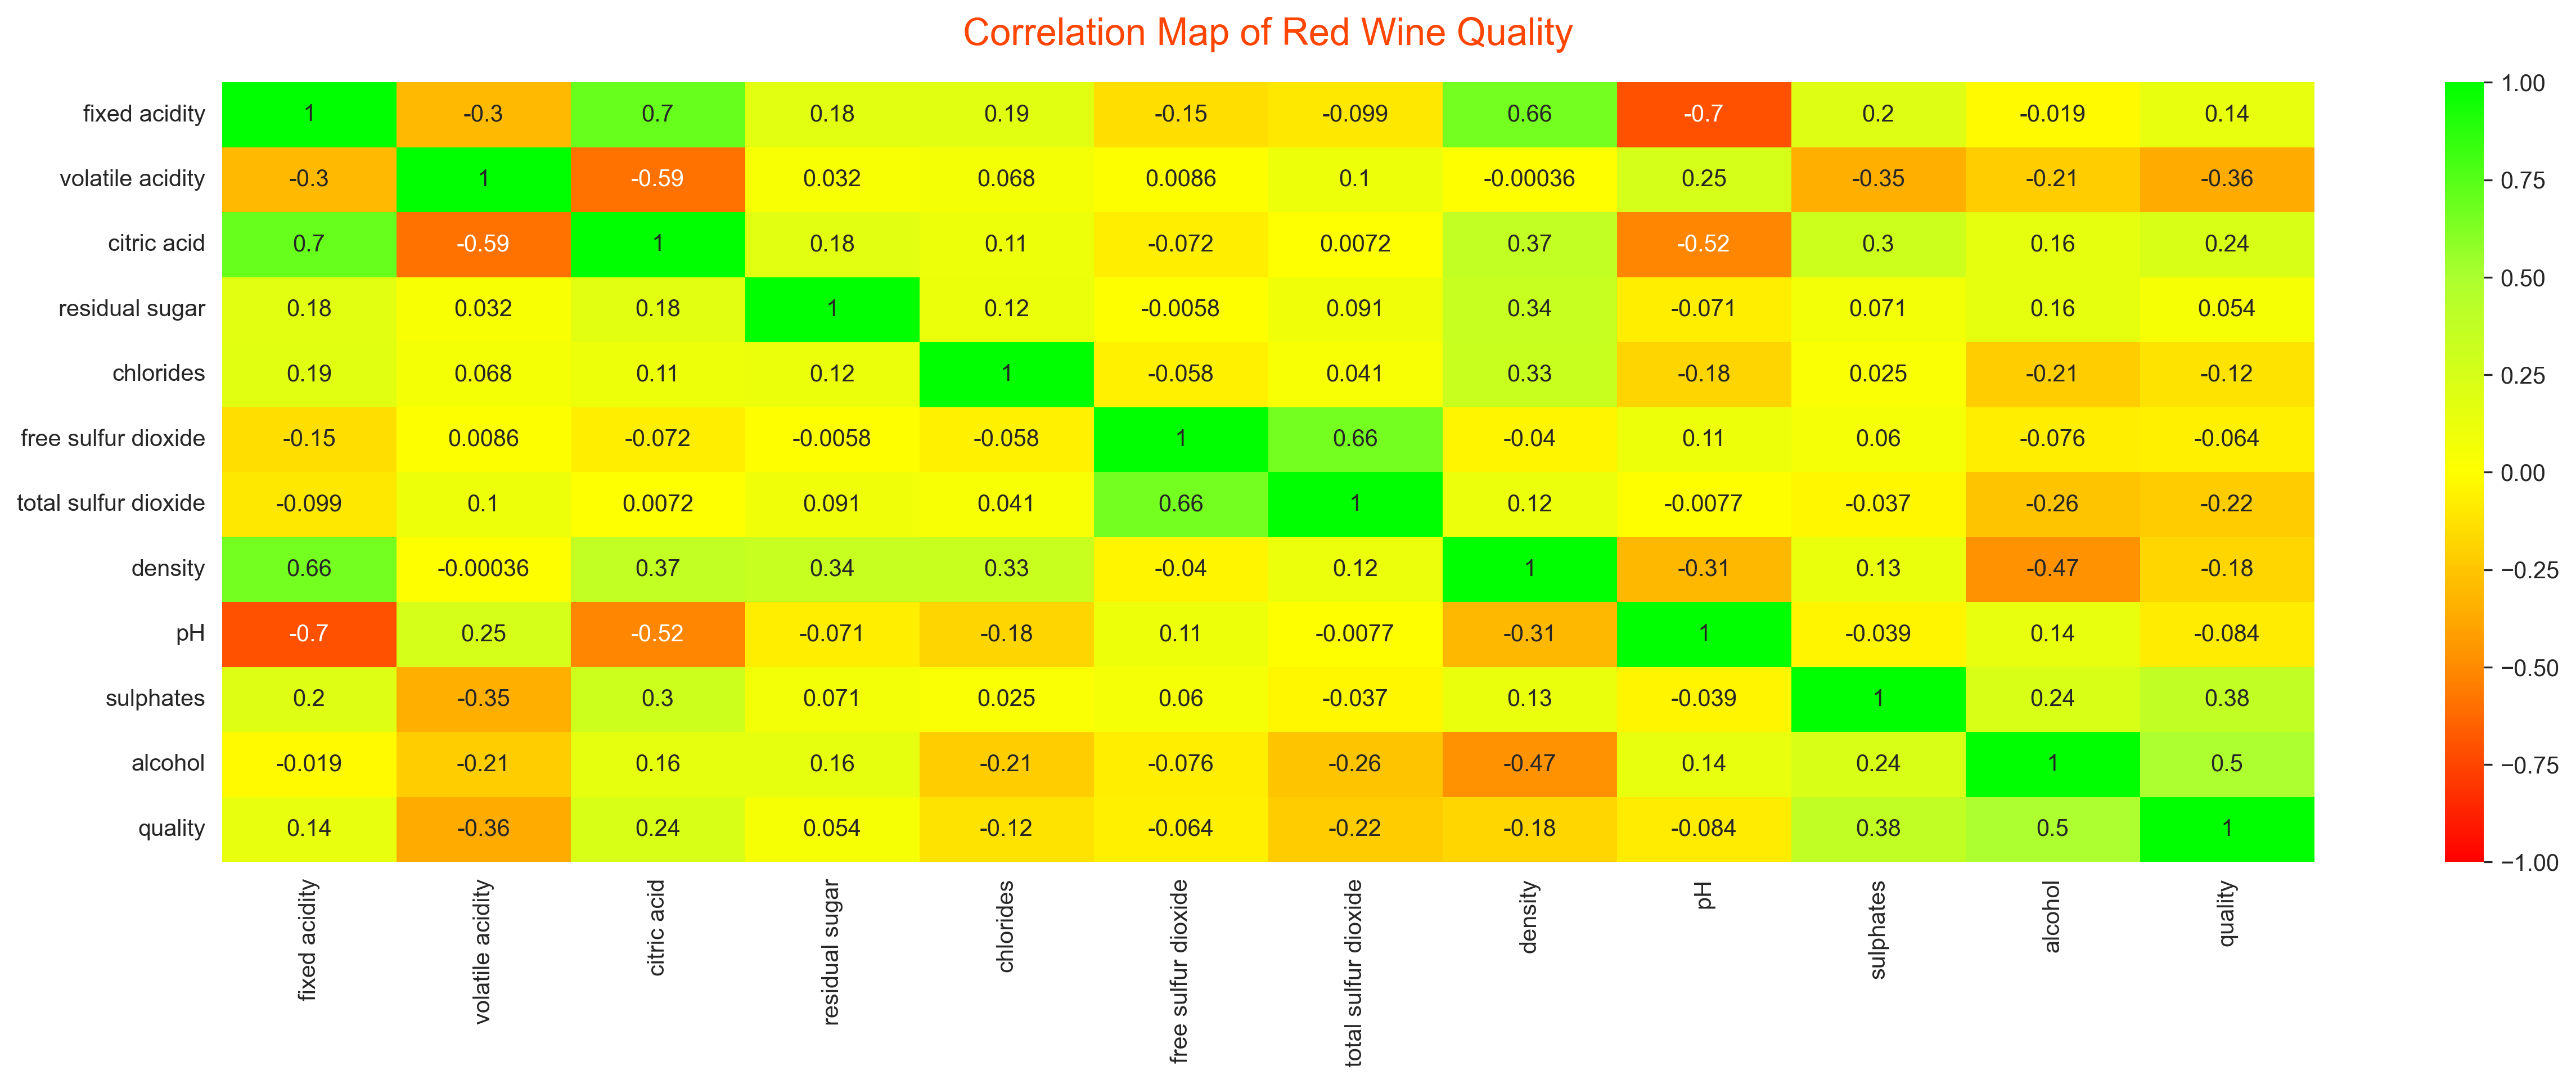

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# colors
bright_vivid_palette = mcolors.LinearSegmentedColormap.from_list("bright_vivid_colors", ["#FF0000", "#FF8C00", "#FFFF00", "#ADFF2F", "#00FF00"])

plt.figure(figsize=(20, 6), dpi=300)

# colors
sns.heatmap(redwine_df.corr(), vmin=-1, vmax=1, annot=True, cmap=bright_vivid_palette, annot_kws={"size": 10})

# titles
plt.title('Correlation Map of Red Wine Quality', fontdict={'fontsize': 16, 'color': '#FF4500'}, pad=16)

# plotting
plt.show()


# Interesting Correlations:

Fixed acidity and pH have a strong negative correlation (-0.68), meaning that as fixed acidity increases, pH decreases.

Alcohol and quality have a moderately positive correlation (0.48), suggesting that higher alcohol content is associated with better quality.

Free sulfur dioxide and total sulfur dioxide have a high positive correlation (0.67), which makes sense since they are related chemically.

Low or Negligible Correlations: Some variables, like chlorides and citric acid, show almost no correlation (0.056), meaning they don’t have a significant linear relationship.

- *If the **quality value >= 6**, it means the quality is **good** and I define it as **1**.*
- *If the **quality value < 6,** it means the quality is **bad** and I define it as **0**.*

#### step 6
##### creating a new column for the binary classification named quality_binary and splitting the data to bad and good quality

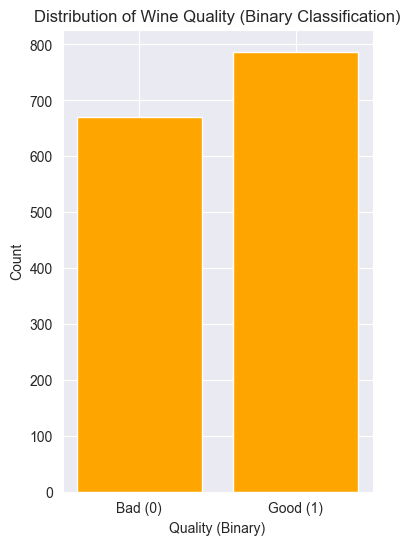

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

# creating a new column for the binary classification named quality_binary
# if the quality value >= 6, it means the quality is good and I define it as 1.
# if the quality value < 6, it means the quality is bad and I define it as 0.
# 0 represents bad quality, 1 represents good quality
redwine_df['quality_binary'] = redwine_df['quality'].apply(lambda x: 0 if x in [3, 4, 5] else 1)

# calculating the value counts of the quality_binary column
quality_binary_counts = redwine_df['quality_binary'].value_counts().sort_index()

# creating a DataFrame from the binary counts
binary_df = pd.DataFrame({'quality_binary': quality_binary_counts.index, 'count': quality_binary_counts.values})

# plotting the bar chart for quality binary (0 = Bad, 1 = Good)
plt.figure(figsize=(4, 6))
plt.bar(binary_df['quality_binary'], binary_df['count'], color='orange')

# lables and title
plt.xticks(binary_df['quality_binary'], labels=['Bad (0)', 'Good (1)'])
plt.xlabel('Quality (Binary)')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality (Binary Classification)')

plt.show()


In [86]:
# dropping the quality column and then renaming the quality_binary column to quality
# now the quality column is the binary column that is going to be used for the binary classification
redwine_df = redwine_df.drop(columns=['quality'], errors='ignore')
redwine_df = redwine_df.rename(columns={'quality_binary': 'quality'})
redwine_df.quality.sample(10)

26      1
366     0
1270    0
1457    1
708     1
904     1
615     0
1183    0
241     1
698     0
Name: quality, dtype: int64

##### checking the corrolation of each column with all the other columns, this pairplot is going to help me to understand the relationship between the columns and the target column, and the columns with eachother.

<Figure size 6000x3000 with 0 Axes>

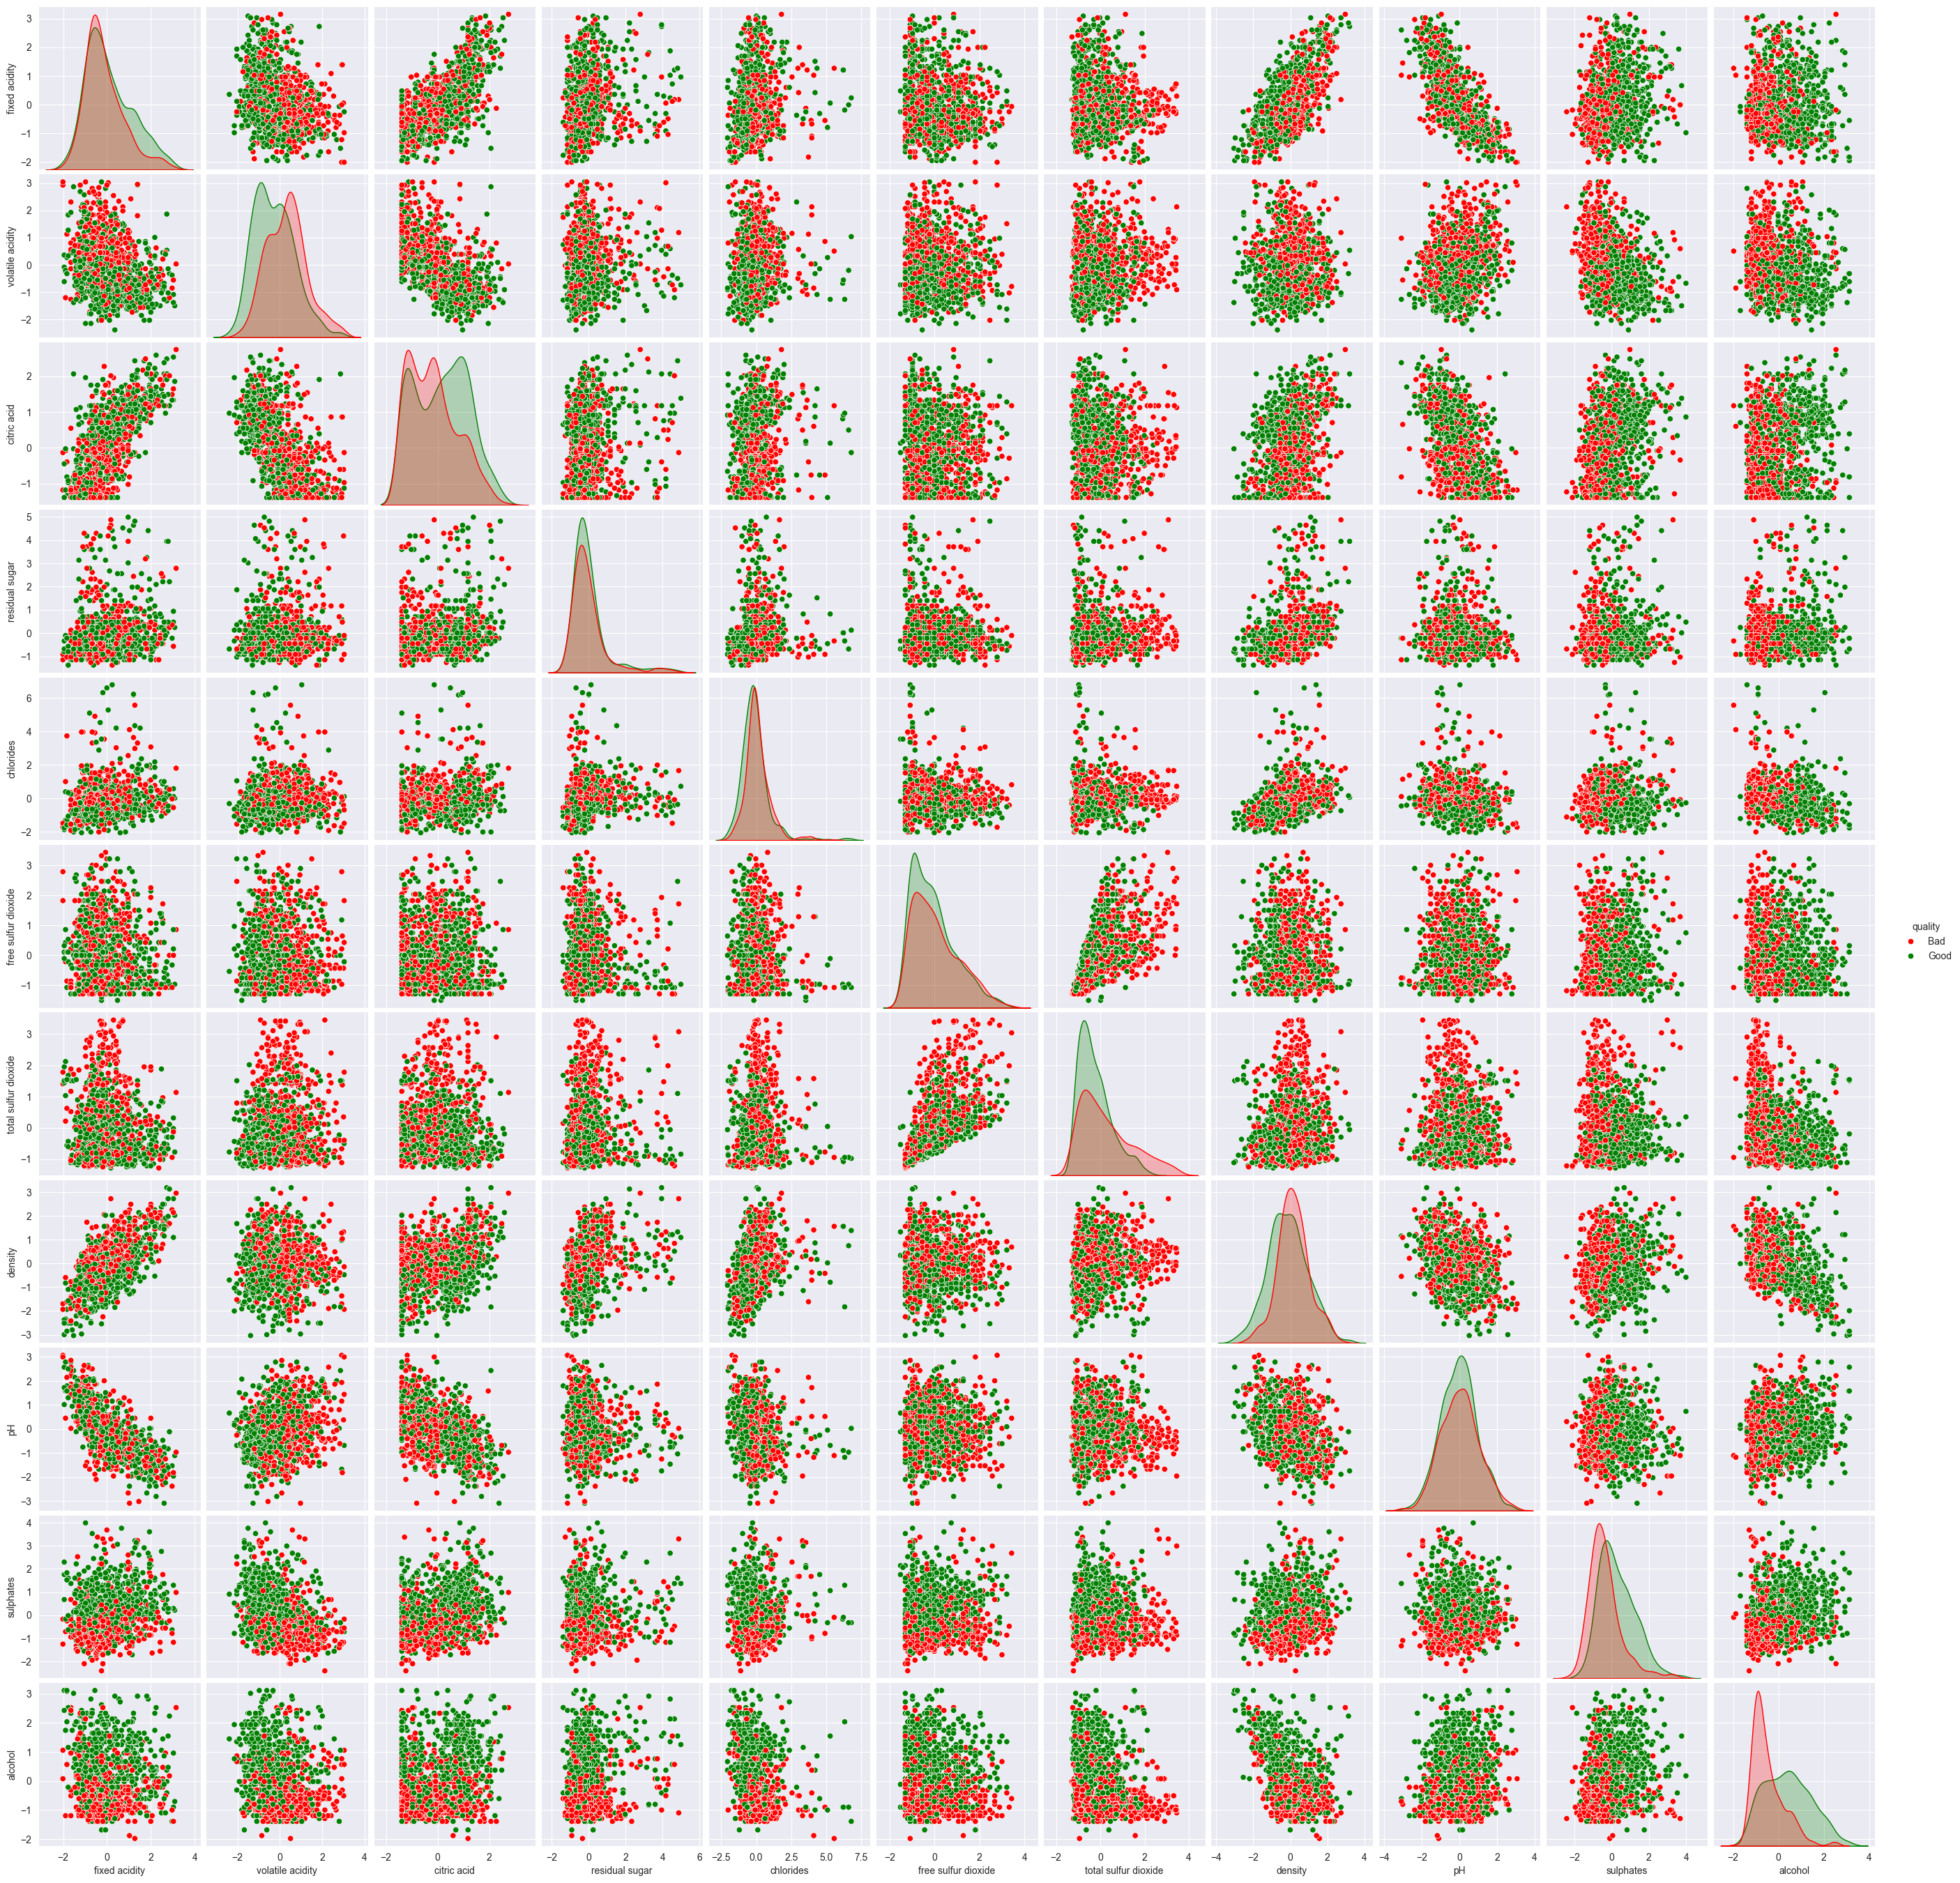

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

redwine_df['quality'] = redwine_df['quality'].map({0: 'Bad', 1: 'Good'})

# making the pair plot
plt.figure(figsize=(20, 10),dpi=300)
sns.pairplot(redwine_df, hue='quality', palette={'Bad': 'red', 'Good': 'green'}, plot_kws={'alpha':1})

# plot
plt.show()


#### step 7
##### finding the best K value for the KNN algorithm

## Find Best K-Score

#### steps
#### 1- splitting the data to train and test
#### 2- finding the best K value. (K value is a value that represents the number of neighbours that the algorithm can take in to account in order to classify a new incomming data point)


In [88]:
X = redwine_df.drop(['quality'], axis = 1)
y = redwine_df['quality']

#### in this scenario because imusing a binary classifier im going to use all features to train the model because there is no imbalance in the data.
#### when I reduce the features I will get an extreme overfitting score and high difference between the training and testing accuracy.

In [89]:
selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = redwine_df[selected_features]
y = redwine_df['quality']
# using standard scaler to scale the data and normalize it
standard_scaler = StandardScaler()
X = standard_scaler.fit_transform(X)
# splitting the data to test and train samples using 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [91]:
X

array([[-0.55385374,  1.03721328, -1.38741253, ...,  1.37249761,
        -0.63538217, -0.99677646],
       [-0.31099096,  2.0989326 , -1.38741253, ..., -0.82379012,
         0.2897715 , -0.60472114],
       [-0.31099096,  1.39111972, -1.17821377, ..., -0.39870217,
         0.05848308, -0.60472114],
       ...,
       [-1.2217264 , -0.08349045, -0.70751654, ...,  0.73486569,
         0.82944447,  0.57144484],
       [-1.46458918,  0.71279904, -0.75981623, ...,  1.79758556,
         0.52105991, -0.21266581],
       [-1.40387349, -1.26317858,  1.07067297, ...,  1.79758556,
         0.13557922,  0.57144484]])

# Find best K
#### this method is going to identify which K score is the best score for my dataset based on train test splitting of the data.

In [92]:
# this function will give a report about the overfitting and underfitting of the model
def analyze_overfitting_underfitting(k_values, overfitting_scores, overfitting_threshold=0.05, underfitting_threshold=-0.05):
    for idx, k in enumerate(k_values):

        overfitting_score = overfitting_scores[idx]

        if overfitting_score > overfitting_threshold:  print(f"At K={k}, the model has overfitting (Overfitting Score: {overfitting_score:.4f}).")

        elif overfitting_score < underfitting_threshold:  print(f"At K={k}, the model has underfitting (Overfitting Score: {overfitting_score:.4f}).")

        else: print(f"At K={k}, no significant overfitting or underfitting detected (Overfitting Score: {overfitting_score:.4f}).")



best k for range 3-25: 10
training accuracy at k=10: 0.7736
testing accuracy at k=10: 0.7740
no significant overfitting or underfitting detected at k = 10


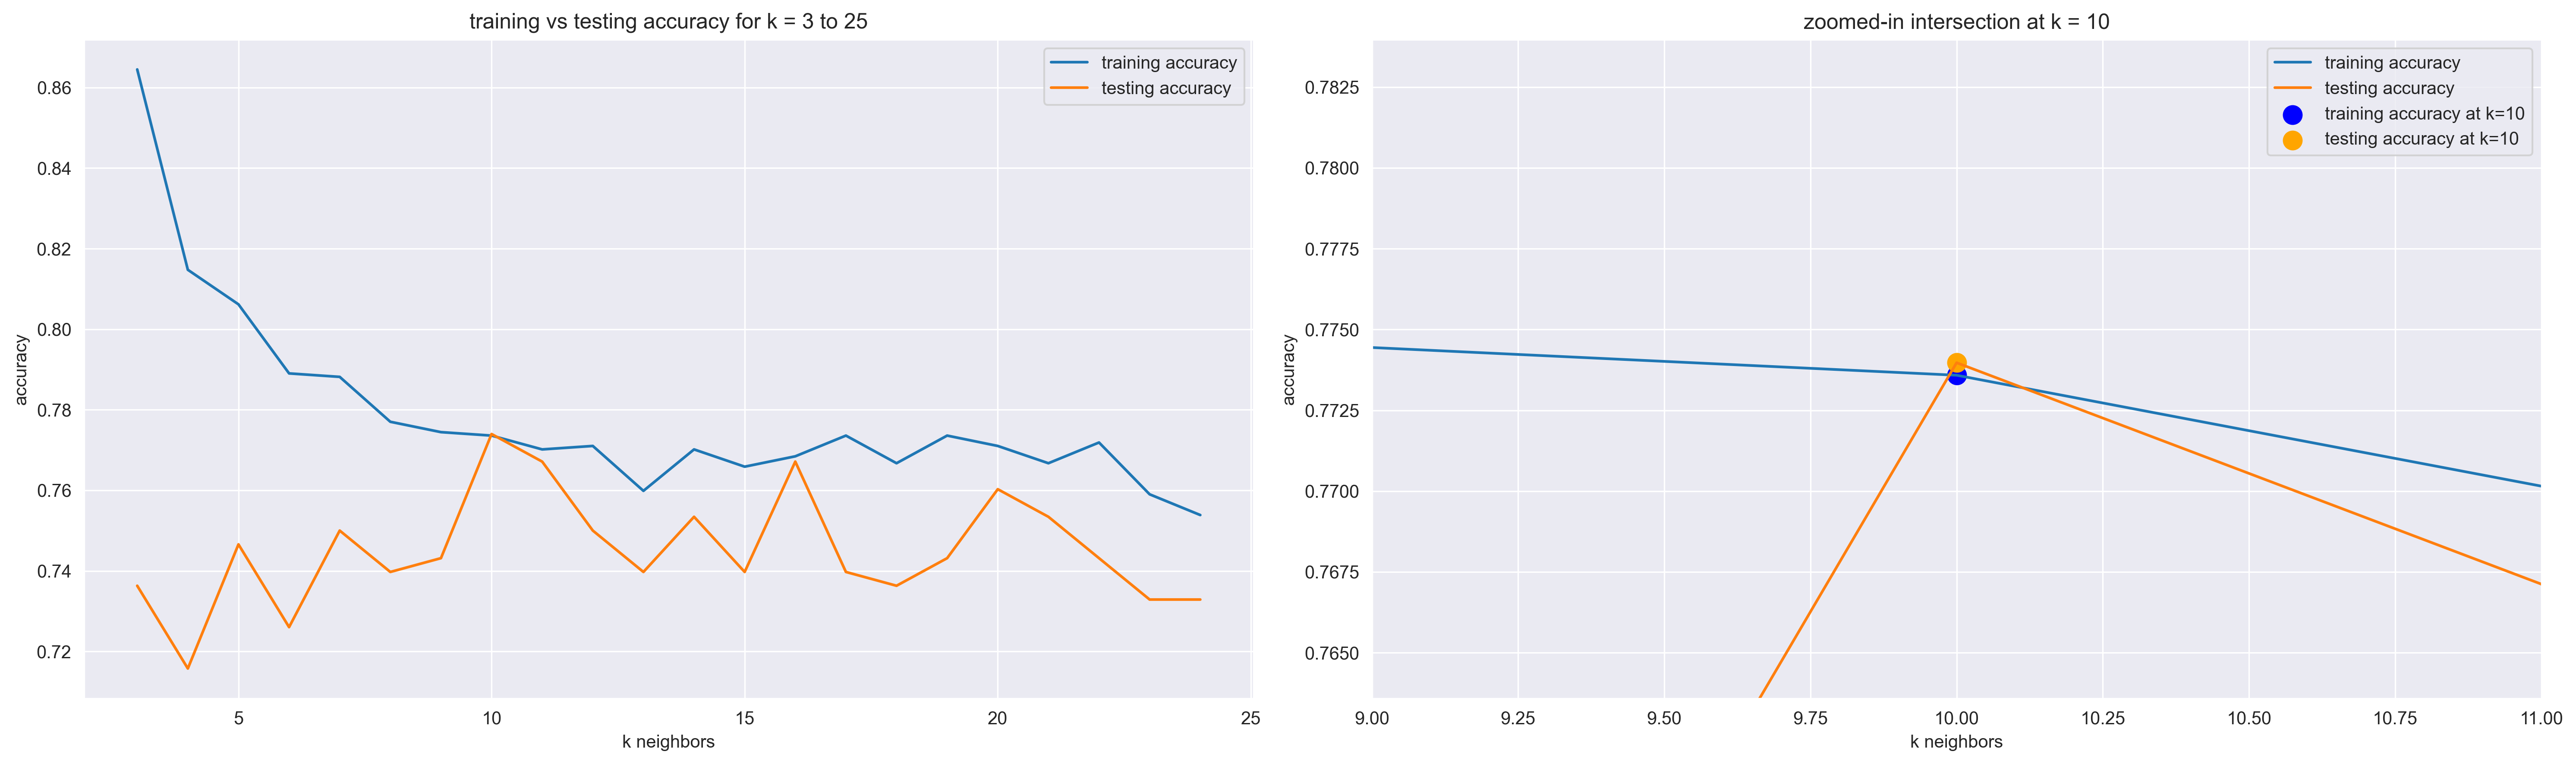

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# this function will find the best k value for the model
def find_best_k(X_train, y_train, X_test, y_test, k_range):
    training_accuracy = []
    testing_accuracy = []
    overfitting_scores = [] 
    best_k = 0
    best_score = 0
    
    k_values = np.arange(k_range[0], k_range[1], k_range[2])

    # iterating over the different k values
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        pipeline = Pipeline([('scaler', StandardScaler()), ('knn', knn)])
        
        # training the model on the training data
        pipeline.fit(X_train, y_train)
        
        # evaluating the model on training data
        train_accuracy = pipeline.score(X_train, y_train)
        training_accuracy.append(train_accuracy)
        
        # evaluating the model on testing data
        test_accuracy = pipeline.score(X_test, y_test)
        testing_accuracy.append(test_accuracy)
        
        # calculating overfitting score
        overfitting_score = train_accuracy - test_accuracy
        overfitting_scores.append(overfitting_score)
        
        # check if this is the best score so far
        if test_accuracy > best_score:
            best_k = k
            best_score = test_accuracy
    
    return best_k, best_score, training_accuracy, testing_accuracy, k_values

# example usage of the function
best_k, best_score, training_accuracy, testing_accuracy, k_values = find_best_k(X_train, y_train, X_test, y_test, k_range=(3, 25, 1))

# get accuracy values for the chosen k
index_best_k = np.where(k_values == best_k)[0][0]
train_accuracy_at_best_k = training_accuracy[index_best_k]
test_accuracy_at_best_k = testing_accuracy[index_best_k]

# print results for the chosen k
print(f"\nbest k for range 3-25: {best_k}")
print(f"training accuracy at k={best_k}: {train_accuracy_at_best_k:.4f}")
print(f"testing accuracy at k={best_k}: {test_accuracy_at_best_k:.4f}")

# determine if there is overfitting, underfitting, or a good fit
overfitting_threshold = 0.05  # define a threshold for overfitting detection
accuracy_difference = train_accuracy_at_best_k - test_accuracy_at_best_k

if accuracy_difference > overfitting_threshold:
    print("the model is overfitting at k =", best_k)
elif accuracy_difference < -overfitting_threshold:
    print("the model is underfitting at k =", best_k)
else:
    print("no significant overfitting or underfitting detected at k =", best_k)

# plotting both the full range and zoomed-in plot side by side
plt.figure(figsize=(20, 6), dpi=300)

# full range plot
plt.subplot(1, 2, 1)
sns.lineplot(x=k_values, y=training_accuracy, label="training accuracy")
sns.lineplot(x=k_values, y=testing_accuracy, label="testing accuracy")
plt.title("training vs testing accuracy for k = 3 to 25")
plt.xlabel("k neighbors")
plt.ylabel("accuracy")
plt.legend()

# zoomed-in plot around k = 10
plt.subplot(1, 2, 2)
sns.lineplot(x=k_values, y=training_accuracy, label="training accuracy")
sns.lineplot(x=k_values, y=testing_accuracy, label="testing accuracy")
plt.xlim(best_k - 1, best_k + 1)  # zoom around best k
plt.ylim(min(train_accuracy_at_best_k, test_accuracy_at_best_k) - 0.01, 
         max(train_accuracy_at_best_k, test_accuracy_at_best_k) + 0.01)
plt.scatter([best_k], [train_accuracy_at_best_k], color="blue", s=100, label="training accuracy at k={}".format(best_k))
plt.scatter([best_k], [test_accuracy_at_best_k], color="orange", s=100, label="testing accuracy at k={}".format(best_k))
plt.title(f"zoomed-in intersection at k = {best_k}")
plt.xlabel("k neighbors")
plt.ylabel("accuracy")
plt.legend()

plt.tight_layout()
plt.show()


For \( K = 10 \):
- **Training Accuracy**: 0.7736
- **Testing Accuracy**: 0.7740
- **Overfitting Score**: -0.0004

### Analysis:
1. **Overfitting Score**: The score is **very close to zero** (-0.0004), indicating no significant gap between training and testing accuracies.
2. **Training and Testing Accuracy**: Both accuracies are reasonably high and nearly identical, suggesting the model generalizes well to unseen data.

### Conclusion:
- This model with \( K = 10 \) is **balanced** and exhibits **no significant overfitting or underfitting**.
- The close alignment of training and testing accuracy implies the model is well-suited to the data, making \( K = 10 \) an excellent choice for this scenario.


##### step 8
#### creating the model with the best k value

In [94]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# making the model with 10 neighbors as was measured in the previous step to be the best k value
knn = KNeighborsClassifier(n_neighbors=10)

# creating the pipeline
pipe_knn = Pipeline([('scale', StandardScaler()), ('knn', knn)])

# fitting the model to the training data
pipe_knn.fit(X_train, y_train)

# making predictions on the test set
y_pred = pipe_knn.predict(X_test)

# evaluating the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with K=10: {accuracy:.4f}")

print("Classification Report:")
report = classification_report(y_test, y_pred, output_dict=True) 
report_df = pd.DataFrame(report).transpose()

report_df.style.background_gradient(axis=0)


Test Accuracy with K=10: 0.7740
Classification Report:


,precision,recall,f1-score,support
Bad,0.720930,0.756098,0.738095,123.000000
Good,0.815951,0.786982,0.801205,169.000000
accuracy,0.773973,0.773973,0.773973,0.773973
macro avg,0.768441,0.771540,0.769650,292.000000
weighted avg,0.775925,0.773973,0.774621,292.000000


##### step 9
##### hyperparameter tuning to find which parameters are the best for the model or with which parameters the model is going to perform the best.

# HyperParameter Tuning

In [95]:
from pprint import pprint
pprint(pipe_knn.get_params(), indent=4)

{   'knn': KNeighborsClassifier(n_neighbors=10),
    'knn__algorithm': 'auto',
    'knn__leaf_size': 30,
    'knn__metric': 'minkowski',
    'knn__metric_params': None,
    'knn__n_jobs': None,
    'knn__n_neighbors': 10,
    'knn__p': 2,
    'knn__weights': 'uniform',
    'memory': None,
    'scale': StandardScaler(),
    'scale__copy': True,
    'scale__with_mean': True,
    'scale__with_std': True,
    'steps': [   ('scale', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=10))],
    'verbose': False}


In [96]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


knn = KNeighborsClassifier()
pipe_knn = Pipeline([('scaler', StandardScaler()), ('knn', knn)])


param_grid = {
    'knn__n_neighbors': [6, 8, 10, 12, 14, 16, 18],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['manhattan', 'euclidean'],
    'knn__algorithm': ['ball_tree', 'kd_tree']
}


grid_search = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fitting the grid search on the training data
grid_search.fit(X_train, y_train)

# getting the best parameters and scores
print("Best hyperparameters found: ", grid_search.best_params_)
best_score = grid_search.best_score_
print(f"Best accuracy score from GridSearchCV: {best_score:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Test Accuracy after Hyperparameter Tuning: {accuracy_score(y_test, y_pred_best):.4f}")
print("Classification Report for Best Model:")

report = classification_report(y_test, y_pred_best, output_dict=True)

report_df = pd.DataFrame(report).transpose()

report_df.style.background_gradient(axis=0)

Best hyperparameters found:  {'knn__algorithm': 'ball_tree', 'knn__metric': 'manhattan', 'knn__n_neighbors': 16, 'knn__weights': 'distance'}
Best accuracy score from GridSearchCV: 0.8002
Test Accuracy after Hyperparameter Tuning: 0.8185
Classification Report for Best Model:


,precision,recall,f1-score,support
Bad,0.782258,0.788618,0.785425,123.000000
Good,0.845238,0.840237,0.842730,169.000000
accuracy,0.818493,0.818493,0.818493,0.818493
macro avg,0.813748,0.814427,0.814078,292.000000
weighted avg,0.818709,0.818493,0.818591,292.000000


##### step 10
##### making the final model using the best parameters from the hyperparameter tuning 

In [97]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# the KNN model with the best parameters from GridSearchCV and StandardScaler
knn_tuned = Pipeline([
    ('knn', KNeighborsClassifier(
        algorithm='ball_tree',
        metric='manhattan',
        n_neighbors=16,
        weights='distance'
    ))
])

# Fit the model with the tuned hyperparameters on the training data
knn_tuned.fit(X_train, y_train)

# predictions on the test set
y_pred = knn_tuned.predict(X_test)

# evaluating the tuned model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy of tuned KNN model: {accuracy:.4f}")


Testing Accuracy of tuned KNN model: 0.8219


#### result of the hyperparameter tuning 
#### before the hyperparameter tuning accuracy was 77.40%
#### after hyperparameter tuning the testing accuracy is 81.85%